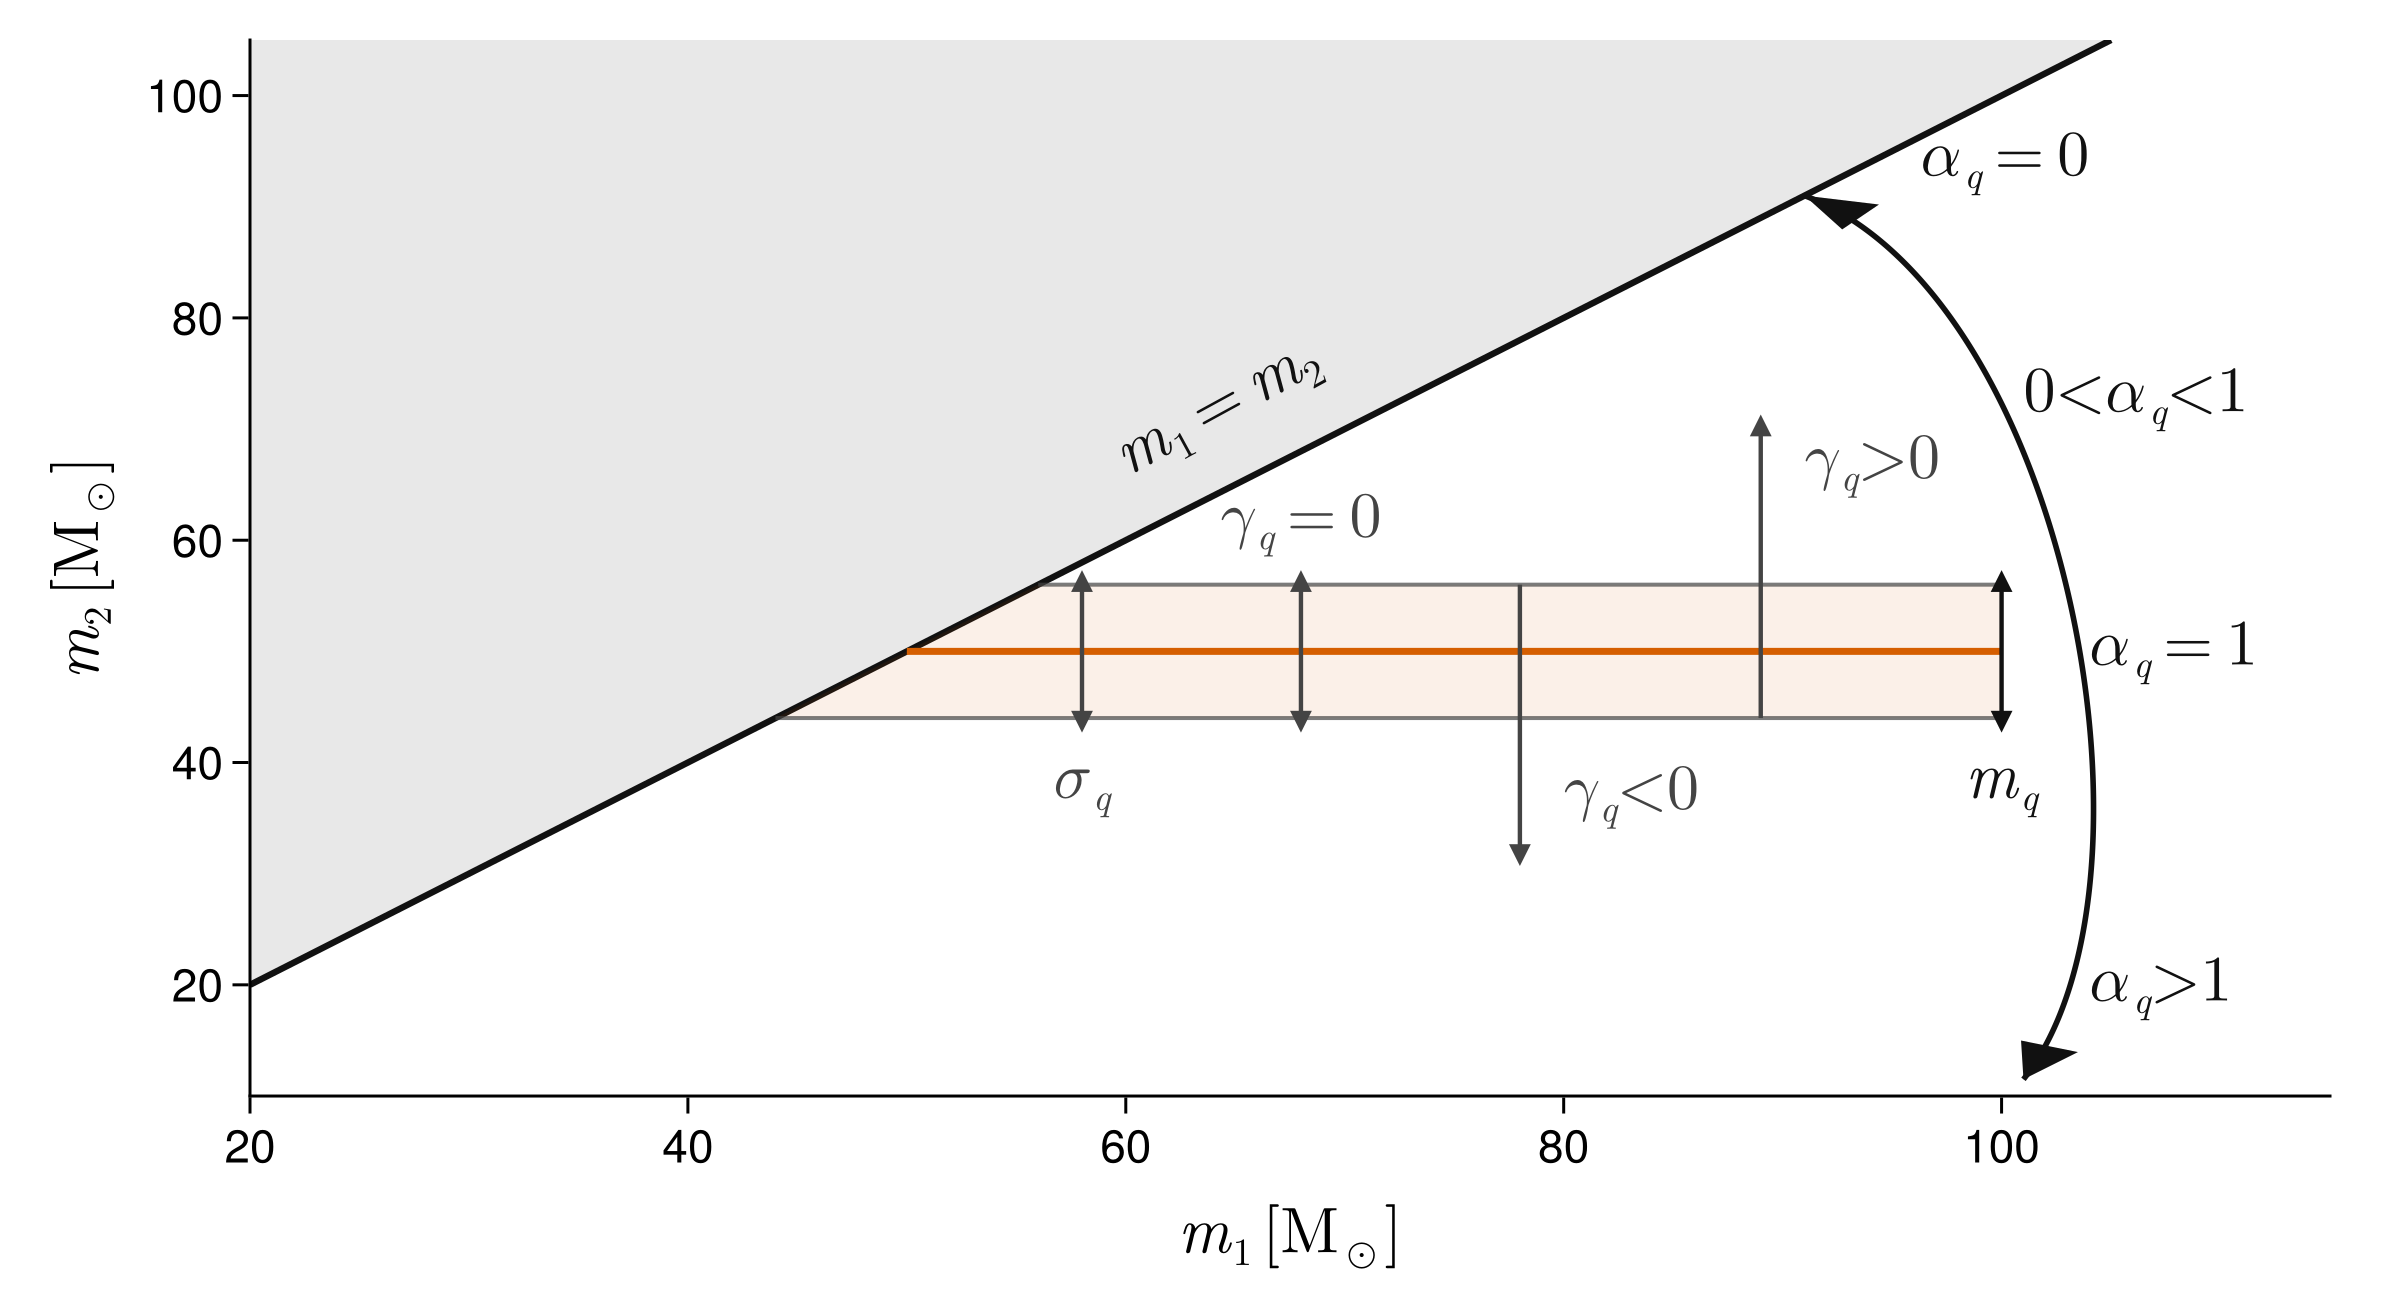

In [24]:
using CairoMakie
using LaTeXStrings

# ============================================================
# Settings
# ============================================================

m_q = 50.0

black    = colorant"#111111"
darkgray = colorant"#444444"
gray     = colorant"#E8E8E8"
orange   = colorant"#D55E00"

# ============================================================
# Figure
# ============================================================

fig = Figure(
    size = (1200, 650),
    fontsize = 24,
    backgroundcolor = :white,
    figure_padding = (25, 35, 15, 20),
)

ax = Axis(
    fig[1, 1],
    xlabel = L"m_1\,[\mathrm{M}_{\odot}]",
    ylabel = L"m_2\,[\mathrm{M}_{\odot}]",
    limits = ((20, 115), (10, 105)),
    xticks = 20:20:120,
    yticks = 20:20:100,
    xlabelsize = 32,
    ylabelsize = 32,
    xticklabelsize = 23,
    yticklabelsize = 23,
    backgroundcolor = :white,
    xgridvisible = false,
    ygridvisible = false,
    spinewidth = 1.5,
    xtickwidth = 1.5,
    ytickwidth = 1.5,
    xticksize = 8,
    yticksize = 8,
    xlabelpadding = 14,
    ylabelpadding = 14,
)

hidespines!(ax, :t, :r)

# ============================================================
# Gray region above the equal-mass boundary
# ============================================================

poly!(
    ax,
    Point2f[
        (20, 20),
        (20, 105),
        (105, 105),
    ];
    color = gray,
    strokewidth = 0,
)

# Equal-mass boundary
m_equal = range(20.0, 105.0, length = 500)

lines!(
    ax,
    m_equal,
    m_equal;
    color = black,
    linewidth = 3.2,
)

# Label inside the gray region and parallel to the boundary
text!(
    ax,
    65,
    69;
    text = L"m_1=m_2",
    color = black,
    fontsize = 32,
    rotation = 0.50,
    align = (:center, :bottom),
)

# ============================================================
# Horizontal ridge around m2 = m_q
# ============================================================

m2_low  = m_q - 6
m2_mid  = m_q
m2_high = m_q + 6

ridge_end = 100.0

# Wedge-shaped band truncated by the equal-mass boundary
poly!(
    ax,
    Point2f[
        (m2_low, m2_low),
        (m2_high, m2_high),
        (ridge_end, m2_high),
        (ridge_end, m2_low),
    ];
    color = (orange, 0.09),
    strokewidth = 0,
)

# Upper edge
lines!(
    ax,
    [m2_high, ridge_end],
    [m2_high, m2_high];
    color = (darkgray, 0.70),
    linewidth = 2,
)

# Central ridge
lines!(
    ax,
    [m2_mid, ridge_end],
    [m2_mid, m2_mid];
    color = orange,
    linewidth = 3.5,
)

# Lower edge
lines!(
    ax,
    [m2_low, ridge_end],
    [m2_low, m2_low];
    color = (darkgray, 0.70),
    linewidth = 2,
)

# ============================================================
# Helper for vertical arrows
# ============================================================

function vertical_arrow!(
    ax,
    x,
    ystart,
    yend;
    color = darkgray,
    linewidth = 2.2,
    arrowsize = 15,
    both = false,
)
    lines!(
        ax,
        [x, x],
        [ystart, yend];
        color = color,
        linewidth = linewidth,
    )

    if yend > ystart
        scatter!(
            ax,
            [x],
            [yend];
            marker = :utriangle,
            markersize = arrowsize,
            color = color,
        )

        if both
            scatter!(
                ax,
                [x],
                [ystart];
                marker = :dtriangle,
                markersize = arrowsize,
                color = color,
            )
        end
    else
        scatter!(
            ax,
            [x],
            [yend];
            marker = :dtriangle,
            markersize = arrowsize,
            color = color,
        )

        if both
            scatter!(
                ax,
                [x],
                [ystart];
                marker = :utriangle,
                markersize = arrowsize,
                color = color,
            )
        end
    end
end

# ============================================================
# sigma_q and gamma_q annotations
# ============================================================

# sigma_q
vertical_arrow!(
    ax,
    58,
    m2_low,
    m2_high;
    both = true,
)

text!(
    ax,
    58,
    m2_low - 2.5;
    text = L"\sigma_q",
    color = darkgray,
    fontsize = 32,
    align = (:center, :top),
)

# gamma_q = 0
vertical_arrow!(
    ax,
    68,
    m2_low,
    m2_high;
    both = true,
)

text!(
    ax,
    68,
    m2_high + 2.5;
    text = L"\gamma_q=0",
    color = darkgray,
    fontsize = 32,
    align = (:center, :bottom),
)

# gamma_q < 0
vertical_arrow!(
    ax,
    78,
    m2_high,
    32;
)

text!(
    ax,
    80,
    34;
    text = L"\gamma_q<0",
    color = darkgray,
    fontsize = 32,
    align = (:left, :bottom),
)

# gamma_q > 0
vertical_arrow!(
    ax,
    89,
    m2_low,
    70;
)

text!(
    ax,
    91,
    67;
    text = L"\gamma_q>0",
    color = darkgray,
    fontsize = 32,
    align = (:left, :center),
)

# ============================================================
# m_q marker at the end of the ridge
# ============================================================

vertical_arrow!(
    ax,
    ridge_end,
    m2_low,
    m2_high;
    color = black,
    linewidth = 2.2,
    arrowsize = 15,
    both = true,
)

text!(
    ax,
    ridge_end,
    m2_low - 2.5;
    text = L"m_q",
    color = black,
    fontsize = 32,
    align = (:center, :top),
)

# ============================================================
# Large curved alpha_q arrow
# ============================================================

# The arrow is placed close to the ridge
P0 = Point2f(91.0, 91.0)   # equal-mass boundary
P1 = Point2f(103.0, 82.0)
P2 = Point2f(108.0, 29.0)
P3 = Point2f(101.0, 11.5)  # m1 axis

t = range(0.0, 1.0, length = 500)

curve_x = @. (
    (1 - t)^3       * P0[1] +
    3 * (1 - t)^2*t * P1[1] +
    3 * (1 - t)*t^2 * P2[1] +
    t^3             * P3[1]
)

curve_y = @. (
    (1 - t)^3       * P0[2] +
    3 * (1 - t)^2*t * P1[2] +
    3 * (1 - t)*t^2 * P2[2] +
    t^3             * P3[2]
)

lines!(
    ax,
    curve_x,
    curve_y;
    color = black,
    linewidth = 2.8,
)

# ============================================================
# Custom arrowheads for the curved arrow
# ============================================================

function arrowhead!(
    ax,
    tip::Point2f,
    direction::Point2f;
    length = 3.2,
    width = 2.8,
    color = black,
)
    direction_norm = sqrt(direction[1]^2 + direction[2]^2)

    ux = direction[1] / direction_norm
    uy = direction[2] / direction_norm

    px = -uy
    py = ux

    base_x = tip[1] - length * ux
    base_y = tip[2] - length * uy

    left = Point2f(
        base_x + 0.5 * width * px,
        base_y + 0.5 * width * py,
    )

    right = Point2f(
        base_x - 0.5 * width * px,
        base_y - 0.5 * width * py,
    )

    poly!(
        ax,
        Point2f[tip, left, right];
        color = color,
        strokewidth = 0,
    )
end

# Upper arrowhead
arrowhead!(
    ax,
    P0,
    Point2f(P0[1] - P1[1], P0[2] - P1[2]),
)

# Lower arrowhead
arrowhead!(
    ax,
    P3,
    Point2f(P3[1] - P2[1], P3[2] - P2[2]),
)

# ============================================================
# alpha_q labels
# ============================================================

# Placed below and to the right of the upper arrowhead
# to avoid the equal-mass boundary
# alpha_q = 0: just above the equal-mass line
text!(
    ax,
    104,
    91;
    text = L"\alpha_q=0",
    color = black,
    fontsize = 32,
    align = (:right, :bottom),
)

# alpha_q = 1: just above the end of the central ridge
text!(
    ax,
    104,
    47;
    text = L"\alpha_q=1",
    color = black,
    fontsize = 32,
    align = (:left, :bottom),
)

text!(
    ax,
    101,
    73;
    text = L"0<\alpha_q<1",
    color = black,
    fontsize = 32,
    align = (:left, :center),
)

text!(
    ax,
    104,
    20;
    text = L"\alpha_q>1",
    color = black,
    fontsize = 32,
    align = (:left, :center),
)

# ============================================================
# Save
# ============================================================

save("m1_m2_schematic.pdf", fig)
save("m1_m2_schematic.svg", fig)
save("m1_m2_schematic.png", fig, px_per_unit = 3)

fig

In [2]:
## Preliminaries

using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using AdvancedHMC
using ArviZ
using BumpCosmologyGWTC3
using CairoMakie
using Colors
using Cosmology
using DataFrames
using DimensionalData
using Distributions
using GaussianKDEs
using HDF5
using InferenceObjects
#using Interpolations
using JSON
using LaTeXStrings
using MCMCChainsStorage
using NCDatasets
using PairPlots
using PolyLog
using PopModels
using Printf
using ProgressLogging
using Random
using StatsBase
using SpecialFunctions
using StatsFuns
using Trapz
using Turing
using Unitful
using UnitfulAstro
using UnitfulChainRules

include("plots.jl")

  Activating project at `~/high_mass_o4b/pop_model3`


h_plot (generic function with 1 method)

# Plot Specification

In [2]:
## Set up paths

## Output Directory for Plots and Astro Comparison Plot
outdir = "../../../Plots/normal_pairing_m2_powerlaws_"

## Plot Specifications
xlabelsize = 30
ylabelsize = 30
xticklabelsize = 23
yticklabelsize = 23
titlesize = 35
draws = 500

plot_save = true

true

### $p_{cut} = 0.5$: Main Plots Use This Trace

In [3]:
trace_samples_0p5 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains_0.5.nc"))
ne_min = dropdims(minimum(trace_samples_0p5.posterior.Neff_samps, dims=(:chain, :draw)); dims=(:chain, :draw))
ns_min = minimum(trace_samples_0p5.posterior.Neff_sel)
@info "p_cut = 0.5, minimum Neff_samps: $(round(minimum(ne_min), digits=2)), minimum Neff_sel = $(round(ns_min, digits=1)), 4*Nobs = $(4*length(dims(trace_samples_0p5.posterior, :event)))"
trace = trace_samples_0p5

┌ Info: p_cut = 0.5, minimum Neff_samps: 4.07, minimum Neff_sel = 1031.9, 4*Nobs = 460
└ @ Main /mnt/home/sroy1/35_GWTC4_Mod/GWTC4_35_m1m2z_Feb23/normal_pairing/m2_powerlaws/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W4sdnNjb2RlLXJlbW90ZQ==.jl:4


InferenceData with groups:
  > posterior
  > sample_stats

### $p_{cut} = 0.1$

In [4]:
trace_samples_0p1 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains_0.1.nc"))

InferenceData with groups:
  > posterior
  > sample_stats

### $p_{cut} = 0.9$

In [5]:
trace_samples_0p9 = from_netcdf(joinpath(@__DIR__, "..", "data", "chains.nc"))

InferenceData with groups:
  > posterior
  > sample_stats

# $m_1-m_2$ Marginals

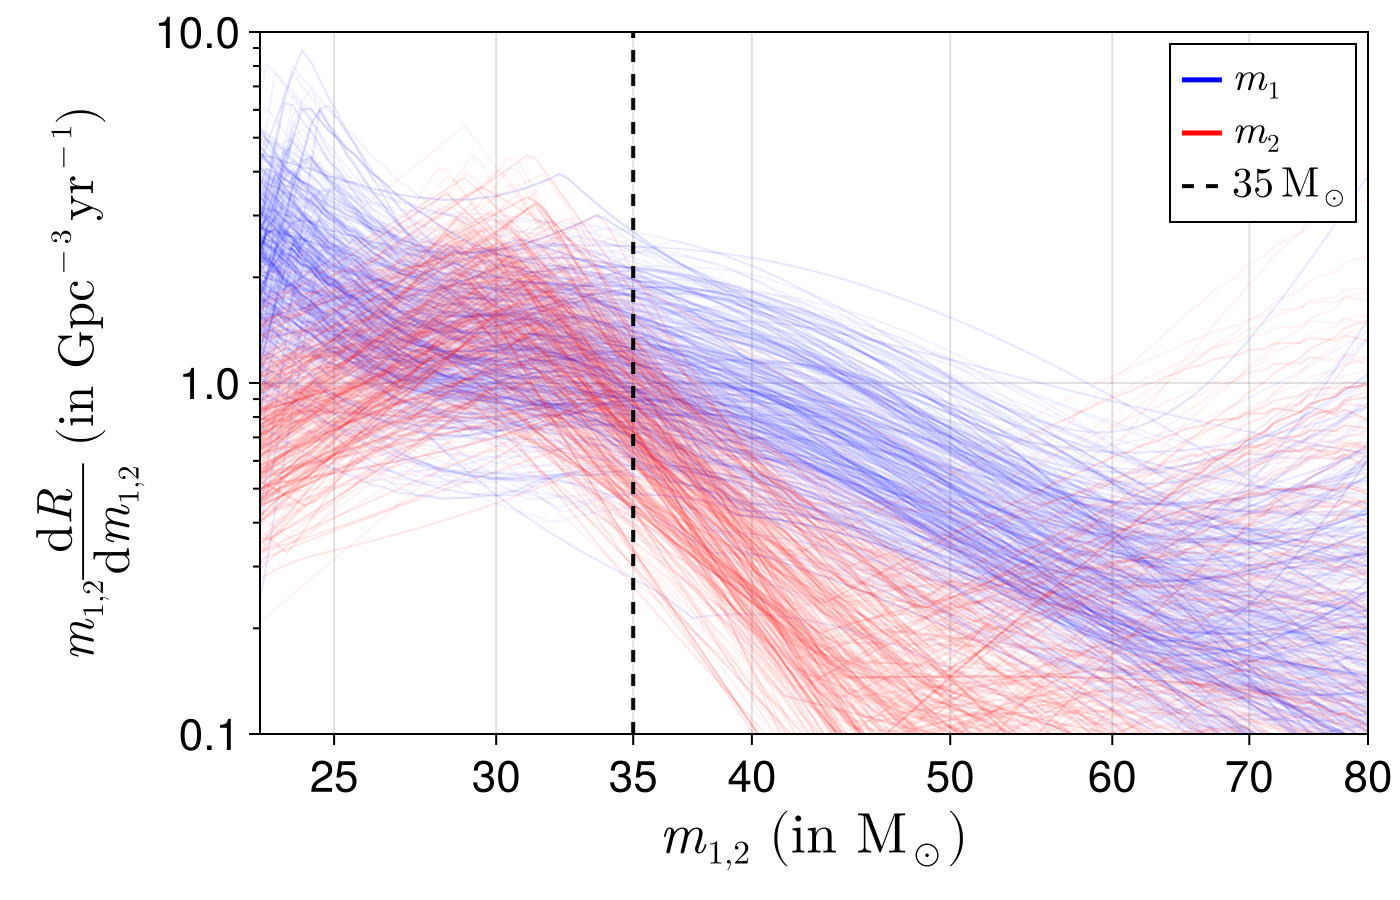

In [6]:
z_plot = 0.0

function marginal_m1m2_plot_paper(trace;
    limits=(23.0, 80.0, 0.1, 10.0),
    yticks=[0.01, 0.1, 1, 10, 100],
    yminorticks=[0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
                 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20],
    draws=1000,
    ntrace=500,
    rng=Random.default_rng()
)

    f = Figure(size=(700, 450))

    a = Axis(f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"m_{1,2} \frac{\mathrm{d} R}{\mathrm{d} m_{1,2}}~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10, yscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        yminorticks = yminorticks,
        yminorticksvisible = true,
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        limits = limits
    )

    marginal_component_plot!(a, trace; kind=:m1, z_plot=z_plot,
        ms=exp.(log(m_bh_min):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        ntrace=ntrace,
        rng=rng,
        color=:blue
    )

    marginal_component_plot!(a, trace; kind=:m2, z_plot=z_plot,
        ms=exp.(log(20.0):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        ntrace=ntrace,
        rng=rng,
        color=:red
    )

    # dummy legend entries
    lines!(a, [NaN], [NaN], color=:blue, linewidth=2.5, label=L"m_1")
    lines!(a, [NaN], [NaN], color=:red, linewidth=2.5, label=L"m_2")

    vlines!(a, [35.0], color=:black, linewidth=2, linestyle=:dash, label=L"35\,\mathrm{M}_\odot")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    return f
end


function marginal_component_plot!(a, trace;
    kind::Symbol, z_plot,
    ms, qs, draws, ntrace,
    rng, color
)

    p = trace.posterior
    sampled_cd = Tuple{Int,Int}[]

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        push!(sampled_cd, (c, d))
    end

    trace_inds = rand(rng, 1:draws, min(ntrace, draws))

    for idx in trace_inds

        c, d = sampled_cd[idx]
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m

            integrand = map(qs) do q

                if kind == :m1
                    m2 = q*m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end

                elseif kind == :m2
                    m1 = m/q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot))/q
                    end
                end
            end

            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        lines!(a, ms, vals, color=(color, 0.05), linewidth=1.0)
    end
end

f = marginal_m1m2_plot_paper(trace; draws=1000, ntrace=500)
f

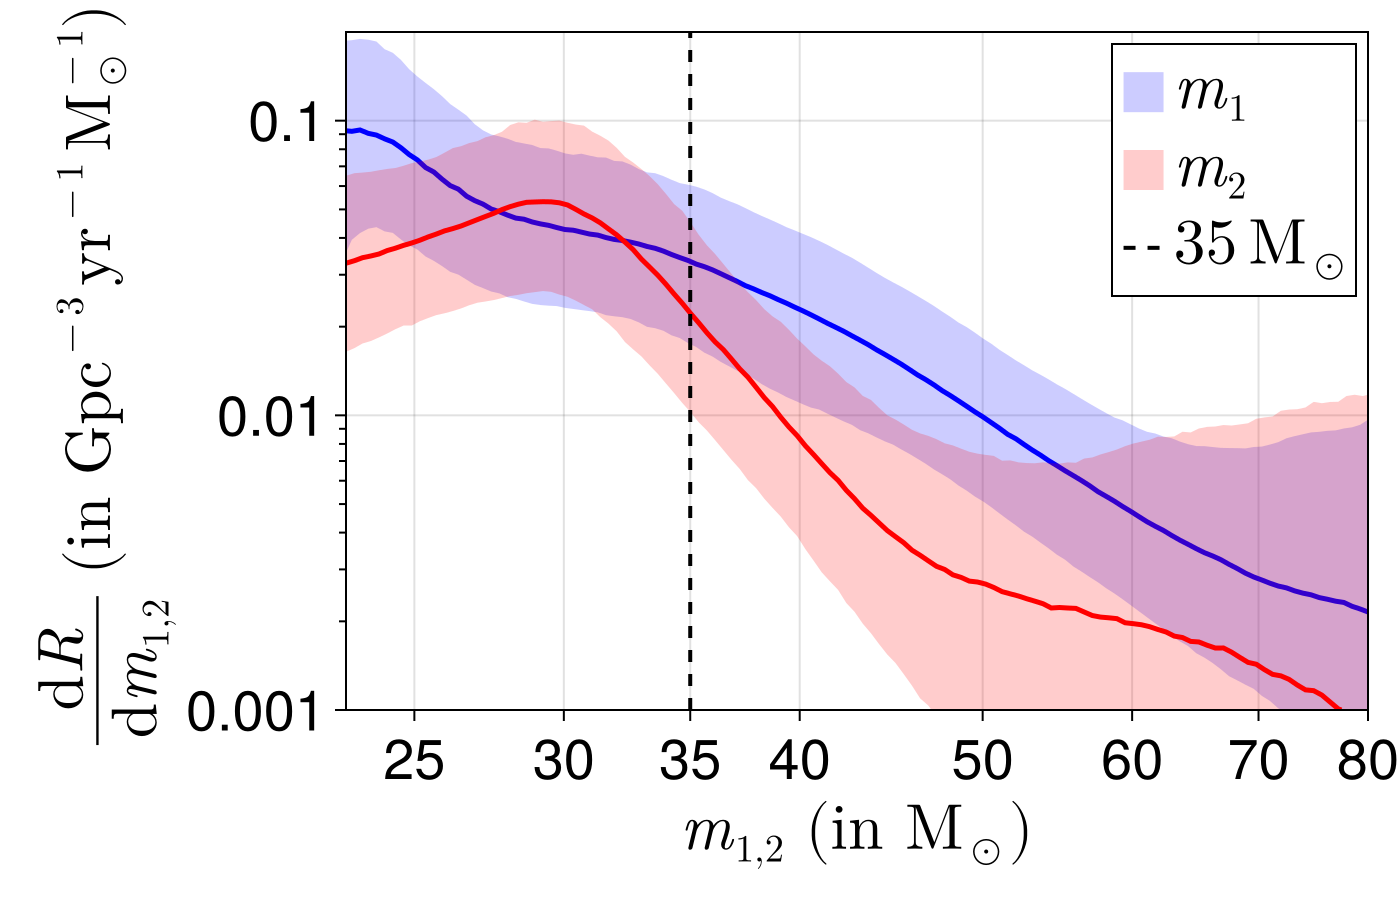

In [7]:
z_plot = 0.0

function marginal_m1m2_plot_paper(trace;
    limits=(23.0, 80.0, 0.001, 0.2),
    yticks=[0.001, 0.01, 0.1, 1, 10],
    yminorticks=[0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,
                 0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
                 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,
                 2,3,4,5,6,7,8,9],
    draws=1000,
    rng=Random.default_rng()
)
    f = Figure(size=(700, 450))
    a = Axis(f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"\frac{\mathrm{d} R}{\mathrm{d} m_{1,2}}~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}\,\mathrm{M}_\odot^{-1})",
        xscale = log10, yscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        yminorticks = yminorticks,
        yminorticksvisible = true,
        xlabelsize = 32,
        ylabelsize = 32,
        xticklabelsize = 28,
        yticklabelsize = 28,
        limits = limits
    )

    marginal_component_plot!(a, trace; kind=:m1, z_plot=z_plot,
        ms=exp.(log(m_bh_min):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        rng=rng,
        color=:blue,
        label=L"m_1"
    )

    marginal_component_plot!(a, trace; kind=:m2, z_plot=z_plot,
        ms=exp.(log(20.0):0.01:log(m_bh_max)),
        qs=0.001:0.01:1,
        draws=draws,
        rng=rng,
        color=:red,
        label=L"m_2"
    )

    vlines!(
        a,
        [35.0],
        color=:black,
        linewidth=2,
        linestyle=:dash,
        label=L"35\,\mathrm{M}_\odot"
    )

    axislegend(a, position=:rt, labelsize=32, framevisible=true)

    f
end


function marginal_component_plot!(a, trace;
    kind::Symbol, z_plot,
    ms, qs, draws,
    rng, color, label
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end
                elseif kind == :m2
                    m1 = m / q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end
                else
                    error("kind must be either :m1 or :m2")
                end
            end
            p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    q5 = mapslices(x -> quantile(x, 0.05), dN_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), dN_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), dN_matrix; dims=2)[:]

    band!(a, ms, q5, q95, color=(color, 0.2), label=label)
    lines!(a, ms, q50, color=color, linewidth=2.5)

    return nothing
end

f = marginal_m1m2_plot_paper(trace)

if plot_save
    save(outdir * "m1m2_marginal_population.pdf", f, px_per_unit=3)
end

f

### Robustness to the Choice of Mass Cut

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.1$

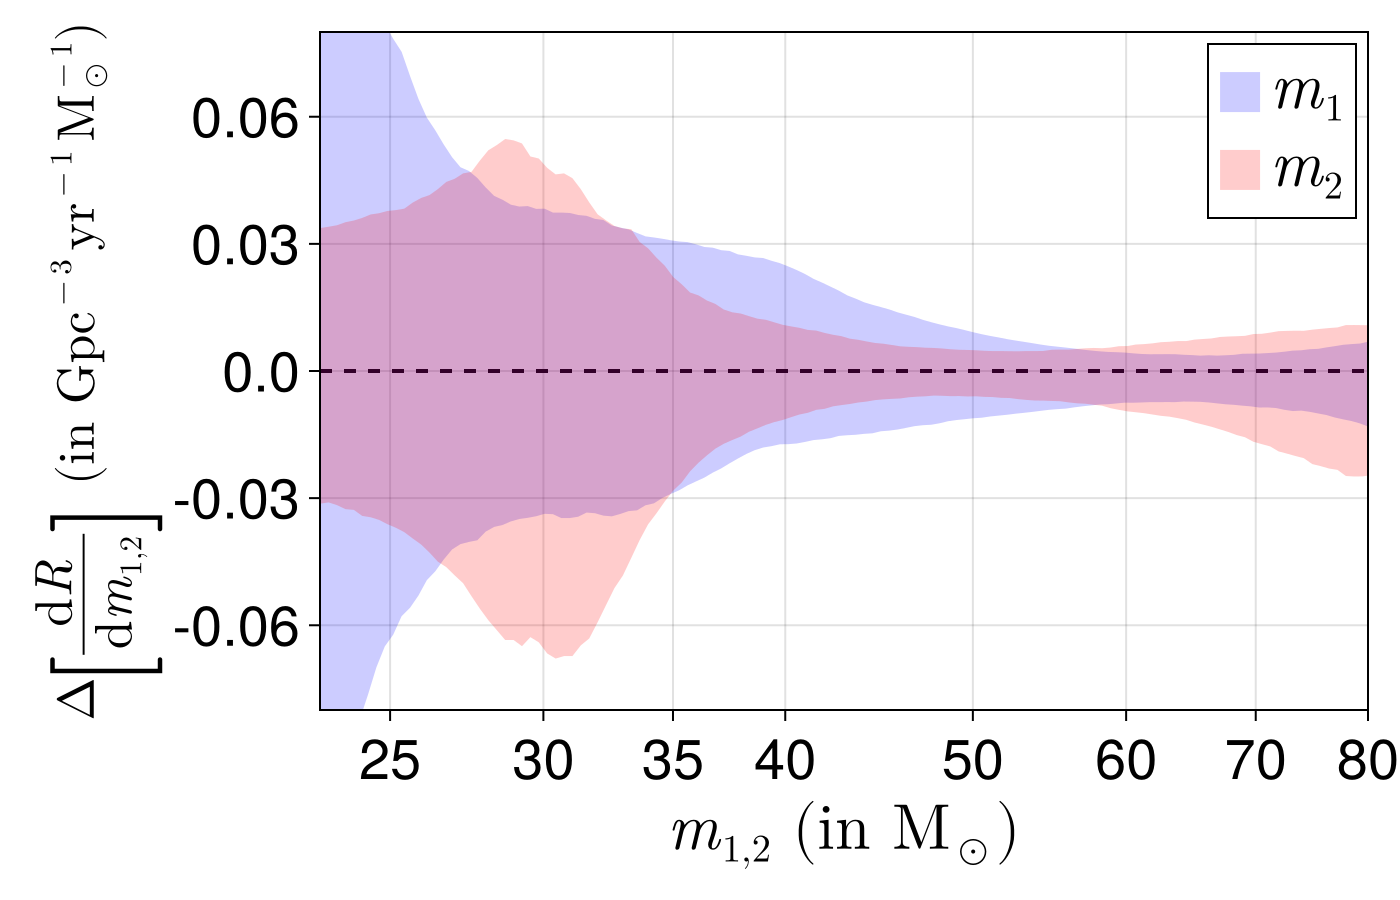

In [8]:
z_plot = 0.0

function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_component_matrix(trace;
    kind::Symbol,
    z_plot,
    ms,
    qs,
    draws,
    rng
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m

                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end

                elseif kind == :m2
                    m1 = m / q

                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end

                else
                    error("kind must be either :m1 or :m2")
                end
            end

            p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    return dN_matrix
end


function marginal_m1m2_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    limits = (23.0, 80.0, -0.08, 0.08),
    yticks = [-0.06, -0.03, 0, 0.03, 0.06],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)
    m1_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m1_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_m1 = m1_matrix_1 .- m1_matrix_2
    diff_m2 = m2_matrix_1 .- m2_matrix_2

    m1_q5, _, m1_q95 = summarize_matrix(diff_m1)
    m2_q5, _, m2_q95 = summarize_matrix(diff_m2)

    f = Figure(size=(700, 450))

    a = Axis(
        f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"\Delta\!\left[\frac{\mathrm{d}R}{\mathrm{d}m_{1,2}}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}\,\mathrm{M}_\odot^{-1})",
        xscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        xlabelsize = 32,
        ylabelsize = 26,
        xticklabelsize = 28,
        yticklabelsize = 28,
        limits = limits,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(
        a,
        [0.0],
        color = :black,
        linewidth = 2,
        linestyle = :dash
    )

    band!(
        a,
        ms_m1,
        m1_q5,
        m1_q95,
        color = (:blue, 0.20),
        label = L"m_1"
    )

    band!(
        a,
        ms_m2,
        m2_q5,
        m2_q95,
        color = (:red, 0.20),
        label = L"m_2"
    )

    axislegend(
        a,
        position = :rt,
        labelsize = 32,
        framevisible = true
    )

    return f
end


f_diff = marginal_m1m2_difference_plot_paper(
    trace,
    trace_samples_0p1;
    z_plot = z_plot,
    limits = (23.0, 80.0, -0.08, 0.08),
    yticks = [-0.06, -0.03, 0, 0.03, 0.06],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)

if plot_save
    save(outdir * "m1m2_marginal_population_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.9$

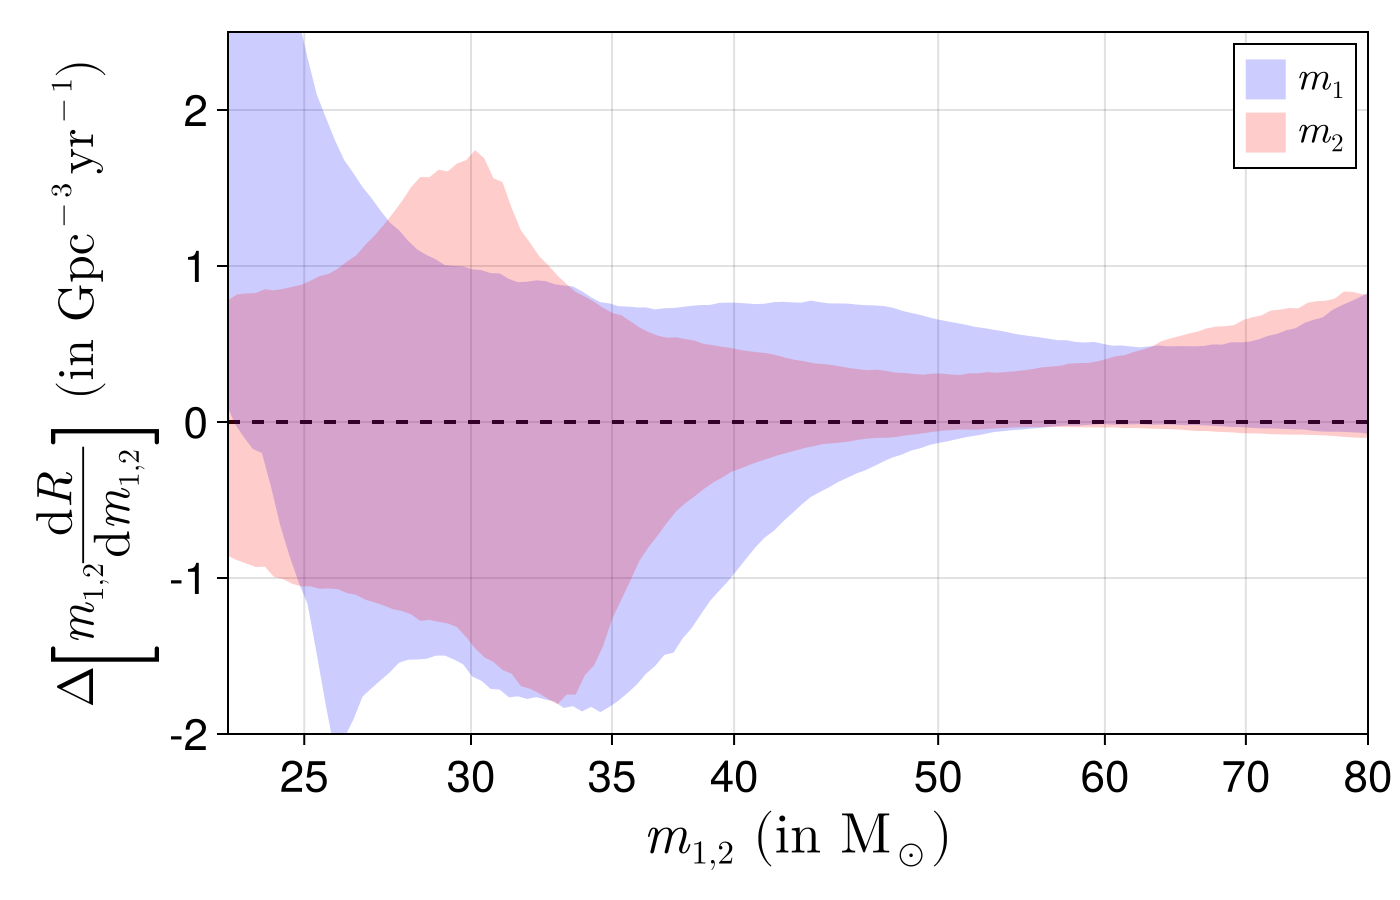

In [9]:
z_plot = 0.0

function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_component_matrix(trace;
    kind::Symbol,
    z_plot,
    ms,
    qs,
    draws,
    rng
)
    p = trace.posterior
    dN_matrix = zeros(length(ms), draws)

    @progress for i in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        vals = map(ms) do m
            integrand = map(qs) do q
                if kind == :m1
                    m2 = q * m
                    if m2 < m_bh_min
                        zero(m)
                    else
                        exp(log_dN(m, q, z_plot))
                    end
                elseif kind == :m2
                    m1 = m / q
                    if m1 < m_bh_min || m1 > m_bh_max
                        zero(m)
                    else
                        exp(log_dN(m1, q, z_plot)) / q
                    end
                end
            end
            m * p.R[chain=c, draw=d] * trapz(qs, integrand)
        end

        dN_matrix[:, i] = vals
    end

    return dN_matrix
end


function marginal_m1m2_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2.5, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)
    m1_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m1_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m1,
        z_plot = z_plot,
        ms = ms_m1,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_1 = marginal_component_matrix(
        trace1;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    m2_matrix_2 = marginal_component_matrix(
        trace2;
        kind = :m2,
        z_plot = z_plot,
        ms = ms_m2,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_m1 = m1_matrix_1 .- m1_matrix_2
    diff_m2 = m2_matrix_1 .- m2_matrix_2

    m1_q5, _, m1_q95 = summarize_matrix(diff_m1)
    m2_q5, _, m2_q95 = summarize_matrix(diff_m2)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1,1],
        xlabel = L"m_{1,2}~(\mathrm{in~}\mathrm{M}_\odot)",
        ylabel = L"\Delta\!\left[m_{1,2}\frac{\mathrm{d}R}{\mathrm{d}m_{1,2}}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        xscale = log10,
        xticks = [25, 30, 35, 40, 50, 60, 70, 80],
        xtickformat = "{:.0f}",
        yticks = (yticks, string.(yticks)),
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        limits = limits,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, ms_m1, m1_q5, m1_q95, color=(:blue, 0.20), label=L"m_1")
    band!(a, ms_m2, m2_q5, m2_q95, color=(:red, 0.20), label=L"m_2")

    axislegend(a, position=:rt, labelsize=21, framevisible=true)

    return f
end


f_diff = marginal_m1m2_difference_plot_paper(
    trace,
    trace_samples_0p9;
    z_plot = z_plot,
    limits = (23.0, 80.0, -2, 2.5),
    yticks = [-2, -1, 0, 1, 2],
    ms_m1 = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    ms_m2 = exp.(log(20.0):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    draws = 1000,
    rng = Random.default_rng()
)

# if plot_save
#     save(outdir * "m1m2_marginal_population_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff

# $q$ Conditioned on $m_1$

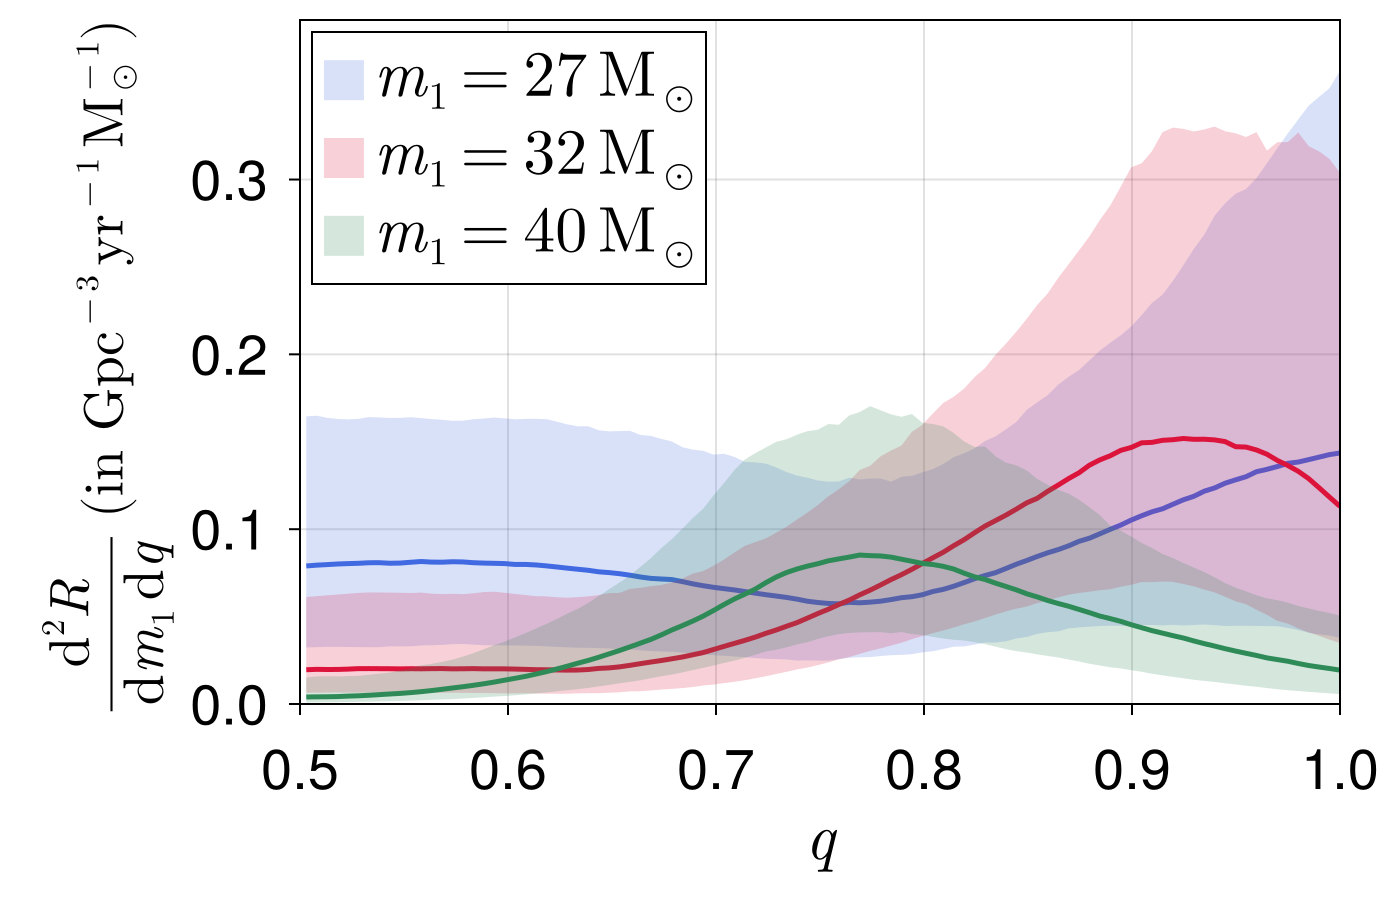

In [10]:
z_plot = 0.0

function conditional_rate_q_given_m1_plot_paper(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 32.0, 40.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    colors = [:royalblue, :crimson, :seagreen]
)

    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    q5_all  = Vector{Vector{Float64}}(undef, nt)
    q50_all = Vector{Vector{Float64}}(undef, nt)
    q95_all = Vector{Vector{Float64}}(undef, nt)

    global_ymax = 0.0

    for (k, m1_fix) in enumerate(m1_targets)

        rate_matrix = zeros(nq, draws)

        @progress for i in 1:draws

            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 > 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrix[:, i] .= vals
        end

        q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
        q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
        q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]

        q5_all[k]  = q5
        q50_all[k] = q50
        q95_all[k] = q95

        sel = qs .>= xlimits[1]
        ymax_here = maximum(q95[sel])
        global_ymax = max(global_ymax, ymax_here)
    end

    f = Figure(
        size = (700, 450),
        figure_padding = (20, 30, 15, 10)
    )

    a = Axis(
        f[1,1],
        xlabel = L"q",
        ylabel = L"\frac{\mathrm{d}^2R}{\mathrm{d}m_1\,\mathrm{d}q} ~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}\,\mathrm{M}_\odot^{-1})",
        limits = (xlimits[1], xlimits[2], 0.0, 1.08 * global_ymax),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 32,
        ylabelsize = 28,
        xticklabelsize = 28,
        yticklabelsize = 28,
        xticklabelpad = 10,
        yticklabelpad = 10,
        xgridvisible = true,
        ygridvisible = true
    )

    for (k, m1_fix) in enumerate(m1_targets)

        q5  = q5_all[k]
        q50 = q50_all[k]
        q95 = q95_all[k]

        valid = (qs .>= xlimits[1]) .& (q95 .> 0)

        band!(
            a,
            qs[valid],
            q5[valid],
            q95[valid],
            color = (colors[k], 0.20),
            label = L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )

        lines!(
            a,
            qs[valid],
            q50[valid],
            color = colors[k],
            linewidth = 2.5
        )
    end

    axislegend(
        a,
        position = :lt,
        labelsize = 32,
        framevisible = true
    )

    return f
end


f = conditional_rate_q_given_m1_plot_paper(trace)

if plot_save
    save(outdir * "q_given_m1_rate.pdf", f, px_per_unit=3)
end

f

### Robustness to the Choice of Mass Cut

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.1$

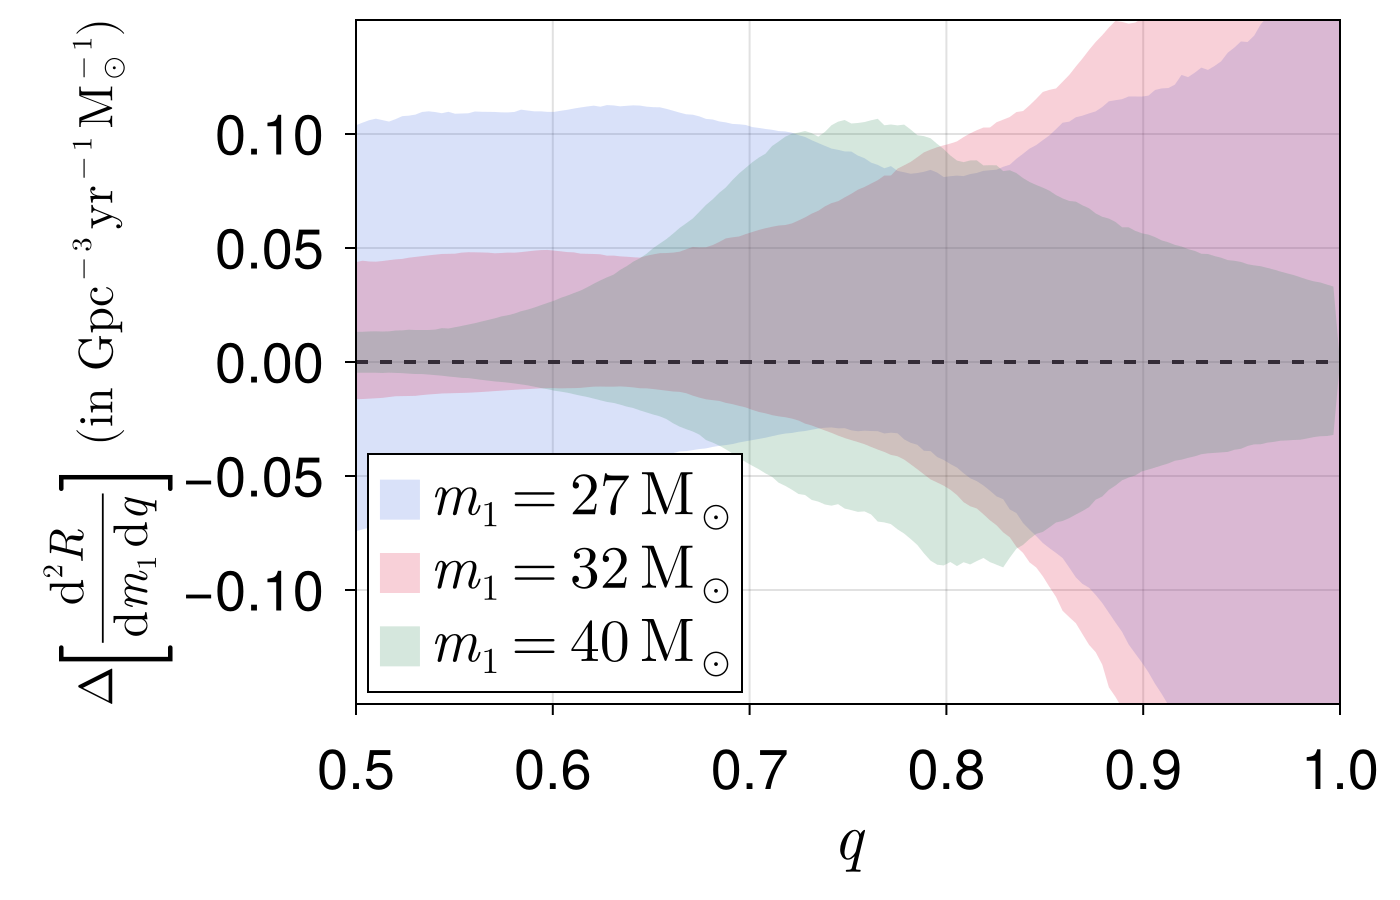

In [11]:
z_plot = 0.0

function conditional_rate_matrix(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 32.0, 40.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng()
)
    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    rate_matrices = [zeros(nq, draws) for _ in 1:nt]

    for (k, m1_fix) in enumerate(m1_targets)
        @progress for i in 1:draws
            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 >= 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrices[k][:, i] .= vals
        end
    end

    return rate_matrices
end


function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function conditional_rate_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    m1_targets = [27.0, 32.0, 40.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-0.15, 0.15),
    colors = [:royalblue, :crimson, :seagreen]
)

    nt = length(m1_targets)

    rate_matrices_1 = conditional_rate_matrix(
        trace1;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    rate_matrices_2 = conditional_rate_matrix(
        trace2;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_q5_all  = Vector{Vector{Float64}}(undef, nt)
    diff_q95_all = Vector{Vector{Float64}}(undef, nt)

    for k in 1:nt
        diff_matrix = rate_matrices_1[k] .- rate_matrices_2[k]
        q5, _, q95 = summarize_matrix(diff_matrix)

        diff_q5_all[k]  = q5
        diff_q95_all[k] = q95
    end

    f = Figure(
        size = (700, 450),
        figure_padding = (20, 30, 15, 10)
    )

    a = Axis(
        f[1, 1],
        xlabel = L"q",
        ylabel = L"\Delta\!\left[\frac{\mathrm{d}^2 R}{\mathrm{d} m_1 \,\mathrm{d} q}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}\,\mathrm{M}_\odot^{-1})",
        limits = (xlimits[1], xlimits[2], ylimits[1], ylimits[2]),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 32,
        ylabelsize = 24,
        xticklabelsize = 28,
        yticklabelsize = 28,
        xticklabelpad = 10,
        yticklabelpad = 10,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(
        a,
        [0.0],
        color = :black,
        linewidth = 2,
        linestyle = :dash
    )

    for (k, m1_fix) in enumerate(m1_targets)
        q5  = diff_q5_all[k]
        q95 = diff_q95_all[k]

        band!(
            a,
            qs,
            q5,
            q95,
            color = (colors[k], 0.20),
            label = L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )
    end

    axislegend(
        a,
        position = :lb,
        labelsize = 30,
        framevisible = true
    )

    return f
end


f_diff = conditional_rate_difference_plot_paper(
    trace,
    trace_samples_0p1;
    z_plot = z_plot,
    m1_targets = [27.0, 32.0, 40.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-0.15, 0.15),
    colors = [:royalblue, :crimson, :seagreen]
)

if plot_save
    save(outdir * "q_given_m1_rate_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

#### with $p_{\rm cut}=0.5$ and $p_{\rm cut}=0.9$

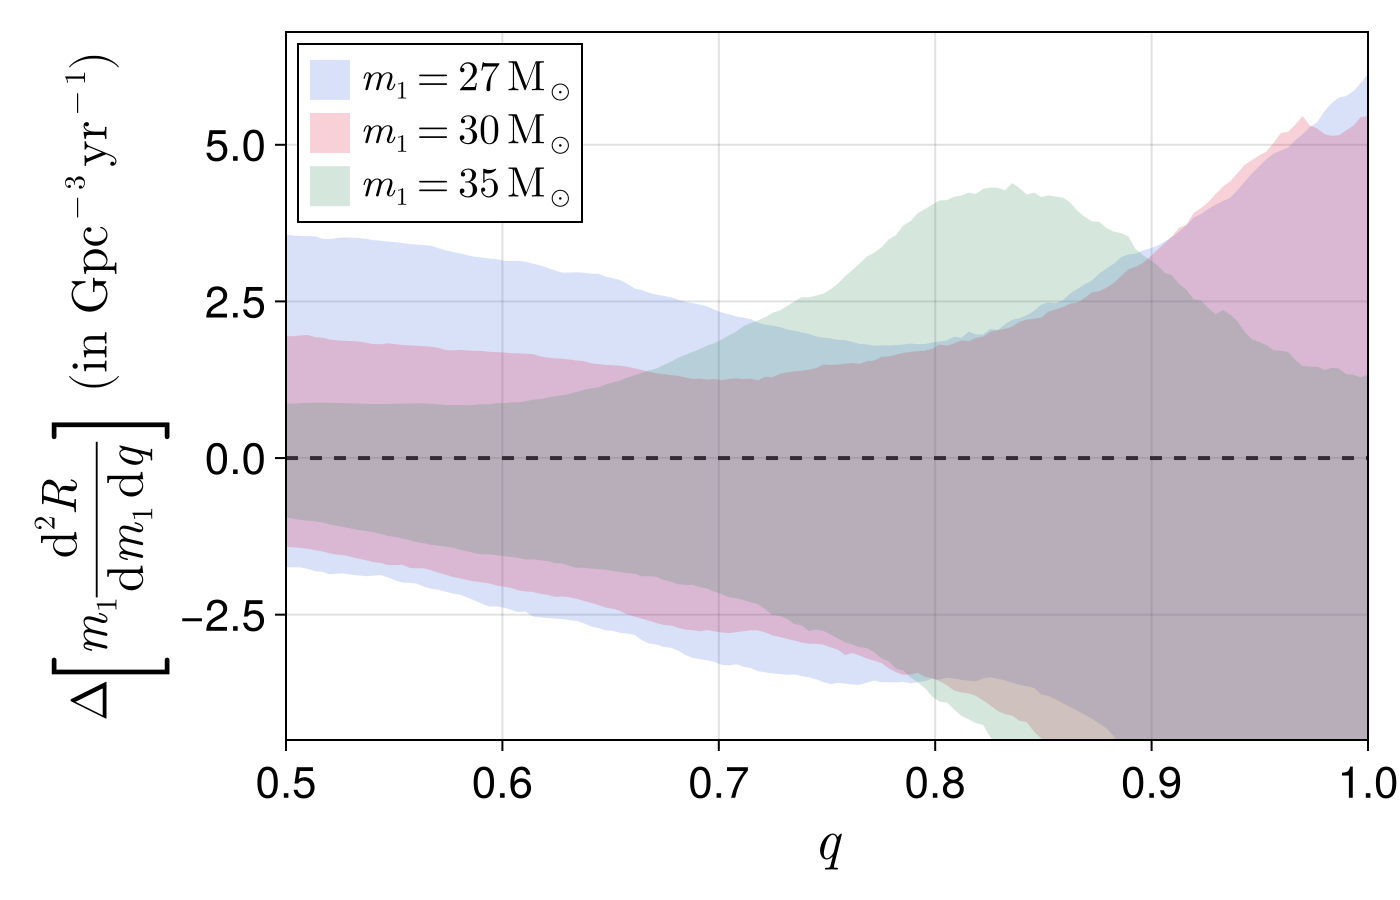

In [12]:
z_plot = 0.0

function conditional_rate_matrix(trace;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.001, stop=1.0, length=200)),
    draws = 1000,
    rng = Random.default_rng()
)
    p = trace.posterior
    nq = length(qs)
    nt = length(m1_targets)

    rate_matrices = [zeros(nq, draws) for _ in 1:nt]

    for (k, m1_fix) in enumerate(m1_targets)
        @progress for i in 1:draws
            d = rand(rng, span(dims(p, :draw)))
            c = rand(rng, 1:length(dims(p, :chain)))

            log_dN = log_dN_from_chain_sample(trace, d, c)
            Rcd = p.R[chain=c, draw=d]

            vals = map(qs) do q
                m2 = q * m1_fix

                if m1_fix <= 25.0 || m2 >= 40.0
                    0.0
                elseif m2 < m_bh_min || m2 > m1_fix || m1_fix > m_bh_max
                    0.0
                else
                    m1_fix * Rcd * exp(log_dN(m1_fix, q, z_plot))
                end
            end

            rate_matrices[k][:, i] .= vals
        end
    end

    return rate_matrices
end


function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function conditional_rate_difference_plot_paper(trace1, trace2;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 4.5),
    colors = [:royalblue, :crimson, :seagreen]
)

    nt = length(m1_targets)

    rate_matrices_1 = conditional_rate_matrix(
        trace1;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    rate_matrices_2 = conditional_rate_matrix(
        trace2;
        z_plot = z_plot,
        m1_targets = m1_targets,
        qs = qs,
        draws = draws,
        rng = rng
    )

    diff_q5_all  = Vector{Vector{Float64}}(undef, nt)
    diff_q95_all = Vector{Vector{Float64}}(undef, nt)

    for k in 1:nt
        diff_matrix = rate_matrices_1[k] .- rate_matrices_2[k]
        q5, _, q95 = summarize_matrix(diff_matrix)

        diff_q5_all[k]  = q5
        diff_q95_all[k] = q95
    end

    f = Figure(size=(700, 450))

    a = Axis(
        f[1, 1],
        xlabel = L"q",
        ylabel = L"\Delta\!\left[m_1 \frac{\mathrm{d}^2 R}{\mathrm{d} m_1 \,\mathrm{d} q}\right]~(\mathrm{in~}\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1})",
        limits = (xlimits[1], xlimits[2], ylimits[1], ylimits[2]),
        xticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        xlabelsize = 28,
        ylabelsize = 25,
        xticklabelsize = 22,
        yticklabelsize = 22,
        xgridvisible = true,
        ygridvisible = true
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    for (k, m1_fix) in enumerate(m1_targets)
        q5  = diff_q5_all[k]
        q95 = diff_q95_all[k]

        band!(
            a,
            qs,
            q5,
            q95,
            color=(colors[k], 0.20),
            label=L"m_1 = %$(Int(round(m1_fix)))\,\mathrm{M}_\odot"
        )
    end

    axislegend(
        a,
        position=:lt,
        labelsize=21,
        framevisible=true
    )

    return f
end


f_diff = conditional_rate_difference_plot_paper(
    trace,
    trace_samples_0p9;
    z_plot = z_plot,
    m1_targets = [27.0, 30.0, 35.0],
    qs = collect(range(0.5, stop=1.0, length=150)),
    draws = 1000,
    rng = Random.default_rng(),
    xlimits = (0.5, 1.0),
    ylimits = (-4.5, 6.8),
    colors = [:royalblue, :crimson, :seagreen]
)

# if plot_save
#     save(outdir * "q_given_m1_rate_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff

# Marginal $z$

imin = 34


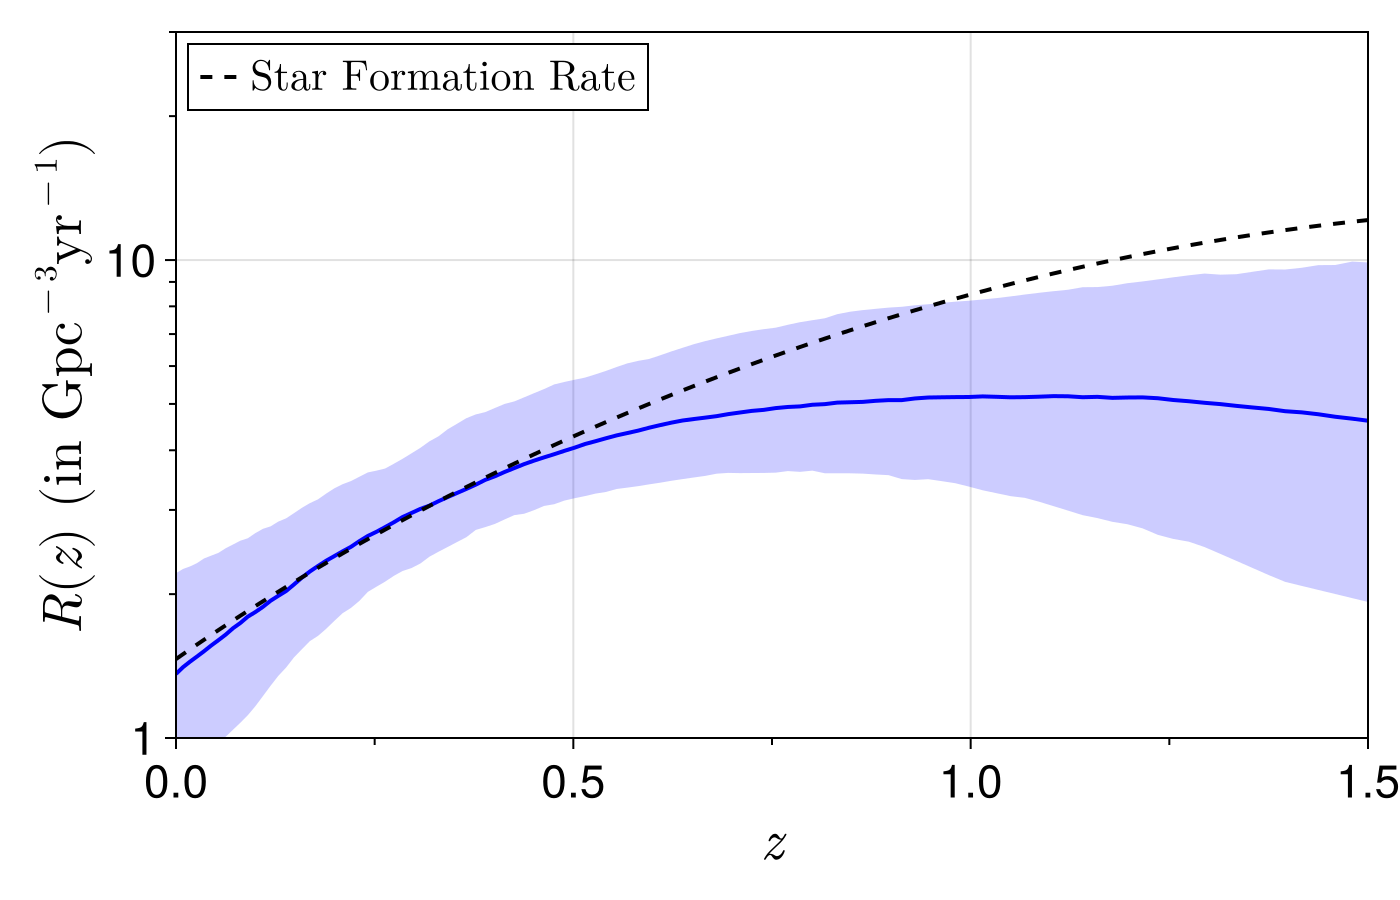

In [13]:
function marginal_z_plot_paper(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, 1, 30),
    yticks = [1, 10, 100, 1000],
    yminorticks = [2,3,4,5,6,7,8,9,20,30,40,50,60,70,80,90,200,300,400,500,600,700,800,900],
    plot_md_line = true,
    color = Makie.wong_colors()[1]
)
    f = Figure(size=(700, 450))
    a = Axis(f[1, 1],
        xlabel = L"z",
        ylabel = L"R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        yscale = log10,
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        yminorticks = yminorticks,
        yminorticksvisible = true,
        xminorticksvisible = true,
        limits = limits
    )

    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    #imin = argmin(Rz_95 - Rz_5)
    vs = vec(var(log.(dNs), dims=2))
    imin = argmin(vs)
    @show imin
    
    medians = mapslices(median, dNs; dims=2)[:]
    lowers = mapslices(x -> quantile(x, 0.05), dNs; dims=2)[:]
    uppers = mapslices(x -> quantile(x, 0.95), dNs; dims=2)[:]
    norm = medians[imin]


    band_plot = band!(a, zs, lowers, uppers, color=(:blue, 0.2))
    median_plot = lines!(a, zs, medians, color=:blue, linewidth=2)

    sfr_plot = nothing
    if plot_md_line
        mds = @. (1 + zs)^2.7 / (1 + ((1 + zs)/(1 + 1.9))^5.6)
        mds = mds .* norm ./ mds[imin]

        sfr_plot = lines!(a, zs, mds, color=:black, linestyle=:dash, linewidth=2, label=L"\mathrm{Star~Formation~Rate}")
    end

    axislegend(a, position = :lt, labelsize = 21, framevisible = true)
    
    return f
end

f = marginal_z_plot_paper(trace)
if plot_save
    save(outdir * "z_marginal_population.pdf", f, px_per_unit=3)
end
f

### Robustness to the Choice of Mass Cut

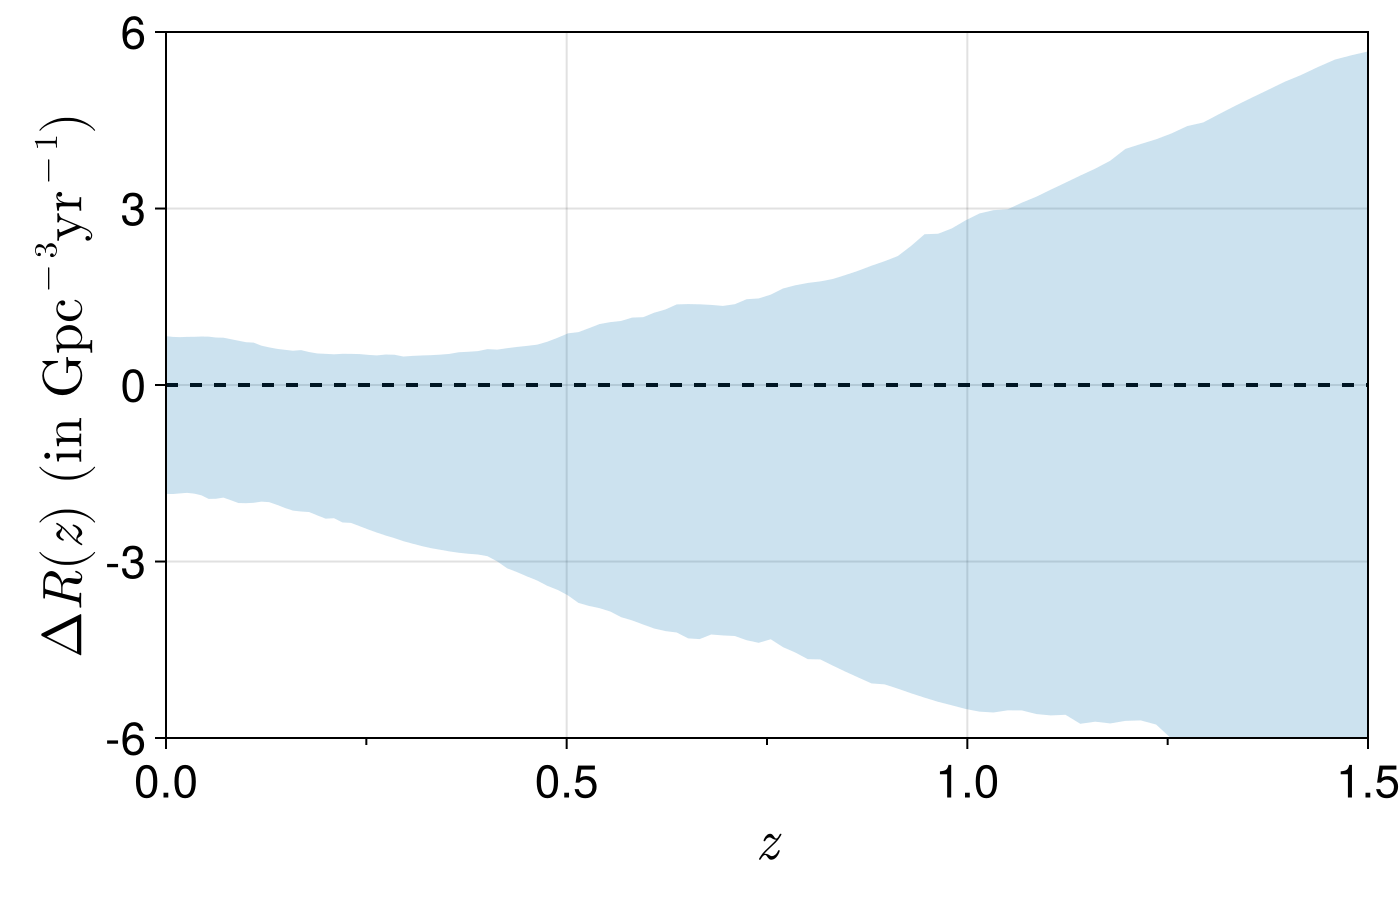

In [14]:
function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_z_matrix(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng()
)
    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    return dNs
end


function marginal_z_difference_plot_paper(trace1, trace2;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)
    dNs1 = marginal_z_matrix(
        trace1;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    dNs2 = marginal_z_matrix(
        trace2;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    diff_dNs = dNs1 .- dNs2
    lowers, _, uppers = summarize_matrix(diff_dNs)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1, 1],
        xlabel = L"z",
        ylabel = L"\Delta R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        xminorticksvisible = true,
        limits = limits
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, zs, lowers, uppers, color=(color, 0.2))

    return f
end

f_diff = marginal_z_difference_plot_paper(
    trace,
    trace_samples_0p1;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)

if plot_save
    save(outdir * "z_marginal_population_diff_0p5_0p1.pdf", f_diff, px_per_unit=3)
end

f_diff

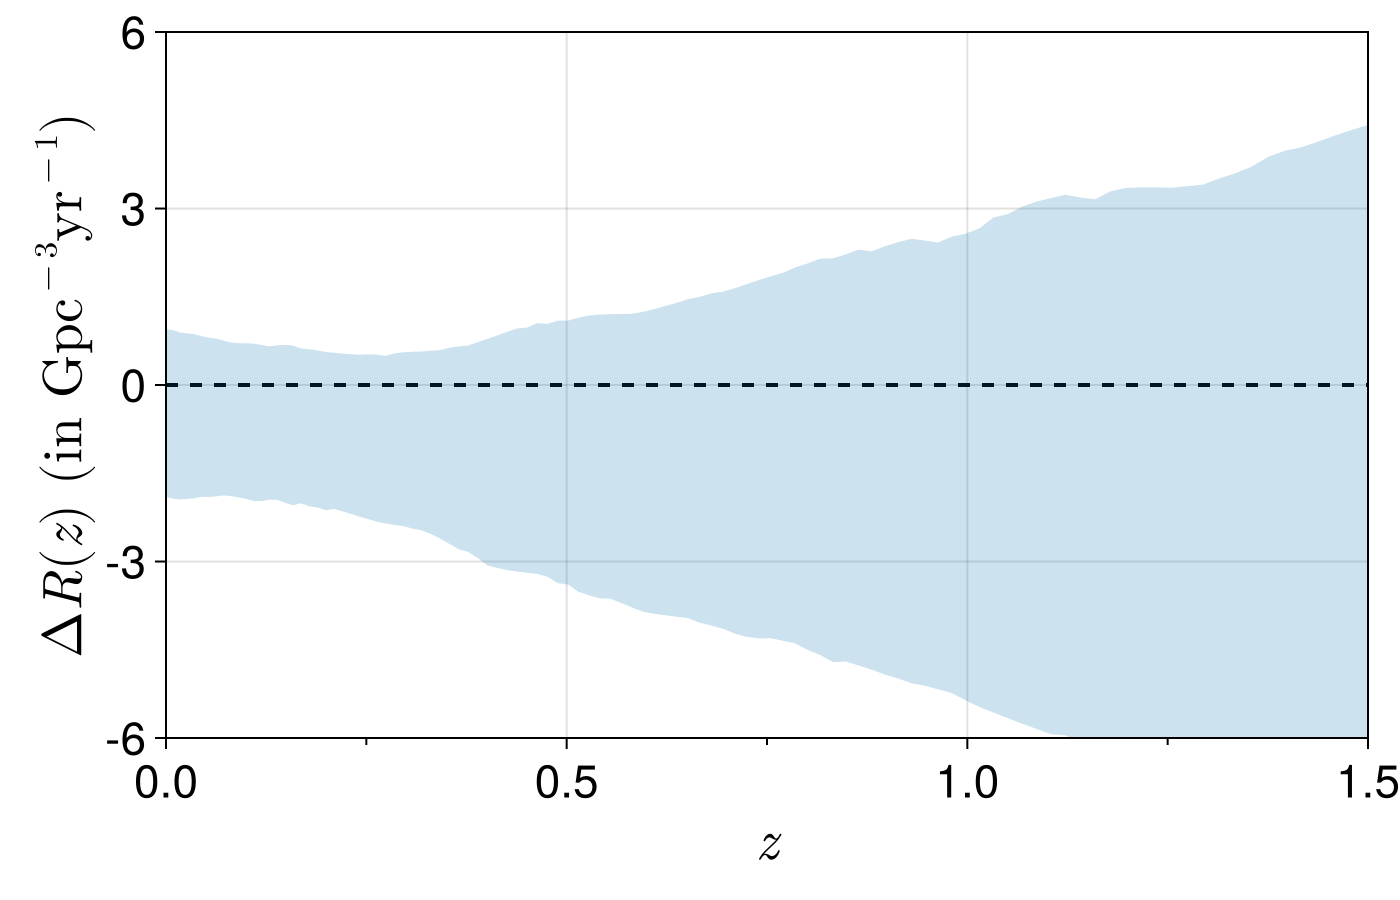

In [15]:
function summarize_matrix(rate_matrix)
    q5  = mapslices(x -> quantile(x, 0.05), rate_matrix; dims=2)[:]
    q50 = mapslices(x -> quantile(x, 0.50), rate_matrix; dims=2)[:]
    q95 = mapslices(x -> quantile(x, 0.95), rate_matrix; dims=2)[:]
    return q5, q50, q95
end


function marginal_z_matrix(trace;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng()
)
    p = trace.posterior
    dNs = zeros(length(zs), draws)

    @progress for j in 1:draws
        c = rand(rng, span(dims(p, :chain)))
        d = rand(rng, span(dims(p, :draw)))
        log_dN = log_dN_from_chain_sample(trace, d, c)

        z1 = zs[1]
        dNdms = map(ms) do m
            integrand = map(qs) do q
                m2 = q * m
                if m2 < m_bh_min
                    zero(m)
                else
                    exp(log_dN(m, q, z1))
                end
            end
            trapz(qs, integrand)
        end

        norm = trace.posterior.R[draw=d, chain=c] *
               trapz(ms, dNdms) /
               exp(log_dN(m_plot, q_plot, z1))

        dNdz = map(zs) do z
            norm * exp(log_dN(m_plot, q_plot, z))
        end

        dNs[:, j] = dNdz
    end

    return dNs
end


function marginal_z_difference_plot_paper(trace1, trace2;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)
    dNs1 = marginal_z_matrix(
        trace1;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    dNs2 = marginal_z_matrix(
        trace2;
        ms = ms,
        qs = qs,
        zs = zs,
        draws = draws,
        rng = rng
    )

    diff_dNs = dNs1 .- dNs2
    lowers, _, uppers = summarize_matrix(diff_dNs)

    f = Figure(size=(700, 450))
    a = Axis(
        f[1, 1],
        xlabel = L"z",
        ylabel = L"\Delta R(z)~(\mathrm{in~}\mathrm{Gpc}^{-3}\mathrm{yr}^{-1})",
        xlabelsize = 28,
        ylabelsize = 28,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        ytickformat = "{:.0f}",
        yticks = yticks,
        xminorticksvisible = true,
        limits = limits
    )

    hlines!(a, [0.0], color=:black, linewidth=2, linestyle=:dash)

    band!(a, zs, lowers, uppers, color=(color, 0.2))

    return f
end

f_diff = marginal_z_difference_plot_paper(
    trace,
    trace_samples_0p1;
    ms = exp.(log(m_bh_min):0.01:log(m_bh_max)),
    qs = 0.001:0.01:1,
    zs = expm1.(range(log(1), stop=log(1 + 2), length=128)),
    draws = draws,
    rng = Random.default_rng(),
    limits = (0, 1.5, -6, 6),
    yticks = [-6, -3, 0, 3, 6],
    color = Makie.wong_colors()[1]
)

# if plot_save
#     save(outdir * "z_marginal_population_diff_0p5_0p9.pdf", f_diff, px_per_unit=3)
# end

f_diff

### Peakiness in $m_1-m_2$ Distribution

In [16]:
using Statistics
using StatsBase
using Random
using ProgressLogging
using Printf
using Dates

z_plot = 0.0
run_name = "Normal Pairing, m2 Powerlaw"

function joint_rate_m1m2_from_chain_sample(trace, d, c, m1s, m2s; z_plot=0.0)
    p = trace.posterior
    log_dN = log_dN_from_chain_sample(trace, d, c)

    Rjoint = fill(NaN, length(m1s), length(m2s))
    Rnorm = p.R[chain=c, draw=d]

    @inbounds for i in eachindex(m1s), j in eachindex(m2s)
        m1 = m1s[i]
        m2 = m2s[j]

        if m2 < m_bh_min || m2 >= m1 || m1 > m_bh_max
            continue
        end

        q = m2 / m1
        Rjoint[i, j] = Rnorm * exp(log_dN(m1, q, z_plot)) / m1
    end

    return Rjoint
end

function find_interior_peaks(R, m1s, m2s; floor_frac=1e-12)
    n1, n2 = size(R)
    dx = m1s[2] - m1s[1]
    dy = m2s[2] - m2s[1]

    peakmask = falses(n1, n2)

    positive_vals = R[isfinite.(R) .& (R .> 0)]
    if isempty(positive_vals)
        return peakmask
    end

    floor_val = maximum(positive_vals) * floor_frac
    logR = fill(NaN, n1, n2)
    valid = falses(n1, n2)

    @inbounds for i in 1:n1, j in 1:n2
        if isfinite(R[i, j]) && R[i, j] > 0
            logR[i, j] = log(max(R[i, j], floor_val))
            valid[i, j] = true
        end
    end

    @inbounds for i in 2:n1-1, j in 2:n2-1
        nbrs = (
            valid[i-1,j-1], valid[i-1,j], valid[i-1,j+1],
            valid[i,  j-1],              valid[i,  j+1],
            valid[i+1,j-1], valid[i+1,j], valid[i+1,j+1]
        )

        if !(valid[i,j] && all(nbrs))
            continue
        end

        center = logR[i,j]
        neighbors = (
            logR[i-1,j-1], logR[i-1,j], logR[i-1,j+1],
            logR[i,  j-1],             logR[i,  j+1],
            logR[i+1,j-1], logR[i+1,j], logR[i+1,j+1]
        )

        if !(center > maximum(neighbors))
            continue
        end

        d2x = (logR[i+1,j] - 2center + logR[i-1,j]) / dx^2
        d2y = (logR[i,j+1] - 2center + logR[i,j-1]) / dy^2
        dxy = (logR[i+1,j+1] - logR[i+1,j-1] - logR[i-1,j+1] + logR[i-1,j-1]) / (4dx*dy)

        trH  = d2x + d2y
        detH = d2x*d2y - dxy^2

        if trH < 0 && detH > 0
            peakmask[i,j] = true
        end
    end

    return peakmask
end

function compute_peak_probability(trace, m1s, m2s;
    draws = 10000,
    rng = Random.default_rng()
)
    has_peak = falses(draws)
    p = trace.posterior

    @progress for k in 1:draws
        d = rand(rng, span(dims(p, :draw)))
        c = rand(rng, 1:length(dims(p, :chain)))

        R = joint_rate_m1m2_from_chain_sample(trace, d, c, m1s, m2s)
        peakmask = find_interior_peaks(R, m1s, m2s)

        has_peak[k] = any(peakmask)
    end

    return mean(has_peak)
end

function compute_peak_probability_batched_and_save(trace;
    run_name = run_name,
    m1_range = (25.0, 40.0),
    m2_range = (25.0, 40.0),
    ngrid = 121,
    batches = 10,
    draws_per_batch = 10000,
    outfile = "../data/peak_diagnostic.txt"
)
    m1s = collect(range(m1_range[1], m1_range[2], length=ngrid))
    m2s = collect(range(m2_range[1], m2_range[2], length=ngrid))

    probs = zeros(batches)

    println("Running $batches batches × $draws_per_batch draws...")

    for b in 1:batches
        rng = MersenneTwister(1234 + b)  # different seed per batch
        println("Batch $b / $batches")

        probs[b] = compute_peak_probability(
            trace, m1s, m2s;
            draws = draws_per_batch,
            rng = rng
        )
    end

    mean_p = mean(probs)
    std_p  = std(probs)

    open(outfile, "w") do io
        @printf(io, "Run Name: %s\n", run_name)
        @printf(io, "Region: 25 <= m2 < m1 <= 40\n")
        @printf(io, "Grid size: %d x %d\n", ngrid, ngrid)
        @printf(io, "Batches: %d\n", batches)
        @printf(io, "Draws per batch: %d\n", draws_per_batch)
        @printf(io, "Mean P(any interior peak) = %.8f (%.5f%%)\n", mean_p, 100*mean_p)
        @printf(io, "Std  P(any interior peak) = %.8f (%.5f%%)\n", std_p, 100*std_p)
        @printf(io, "All batch values: %s\n", string(probs))
    end

    println("\nFinal result:")
    println("Mean P = ", round(100*mean_p; digits=5), "%")
    println("Std  P = ", round(100*std_p; digits=5), "%")

    return mean_p, std_p, probs
end

mean_p, std_p, probs = compute_peak_probability_batched_and_save(
    trace;
    run_name = run_name,
    batches = 10,
    draws_per_batch = 10000
)

Running 10 batches × 10000 draws...
Batch 1 / 10
Batch 2 / 10
Batch 3 / 10
Batch 4 / 10
Batch 5 / 10
Batch 6 / 10
Batch 7 / 10
Batch 8 / 10
Batch 9 / 10
Batch 10 / 10

Final result:
Mean P = 36.445%
Std  P = 0.35199%


(0.36445000000000005, 0.0035198642650597287, [0.3665, 0.3642, 0.359, 0.3677, 0.3641, 0.3631, 0.367, 0.3594, 0.3701, 0.3634])